# Chapter 04: MNIST foundations

In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.5 MB/s eta 0:00:00


In [2]:
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

## Section: Images & Tensors

### Ex 1: Images as data

In [3]:
samples = untar_data(URLs.MNIST_SAMPLE)
samples

<div><progress max="3214948" value="3219456"></progress> 100.14% [3219456/3214948 00:00&lt;00:00]</div>

Path('/root/.fastai/data/mnist_sample')

In [4]:
samples.ls()

[Path('/root/.fastai/data/mnist_sample/valid'), Path('/root/.fastai/data/mnist_sample/labels.csv'), Path('/root/.fastai/data/mnist_sample/train')]

In [5]:
Path.BASE_PATH = samples
samples

Path('.')

In [6]:
!ls $samples/'train/3'

10000.png  17470.png  25210.png  33283.png  41136.png  48932.png  5640.png
10011.png  17471.png  25222.png  33299.png  41143.png  48935.png  56420.png
10031.png  17491.png  25225.png  33316.png  41165.png  48965.png  5642.png
10034.png  17496.png  25231.png  3332.png   41171.png  48974.png  56434.png
10042.png  17509.png  25245.png  33331.png  41212.png  48978.png  56437.png
10052.png  17521.png  2524.png	 33344.png  4121.png   48981.png  56448.png
10074.png  17526.png  25257.png  33351.png  41225.png  4898.png   56449.png
1007.png   17553.png  25266.png  33357.png  41229.png  48995.png  56457.png
10091.png  17569.png  25282.png  3336.png   41233.png  48998.png  56474.png
10093.png  1756.png   25284.png  33371.png  41267.png  49006.png  56475.png
10097.png  17574.png  25291.png  33399.png  41283.png  49018.png  56488.png
10099.png  17575.png  25296.png  33400.png  41287.png  49020.png  56492.png
10116.png  17580.png  2529.png	 33407.png  41299.png  49054.png  56495.png
10125.png  17582

In [7]:
train_threes = (samples / 'train/3').ls().sorted()
train_sevens = (samples / 'train/7').ls().sorted()
valid_threes = (samples / 'valid/3').ls().sorted()
valid_sevens = (samples / 'valid/7').ls().sorted()

len(train_threes), len(train_sevens), len(valid_threes), len(valid_sevens)

(6131, 6265, 1010, 1028)

In [8]:
a_3 = Image.open(train_threes[0])
a_3

In [9]:
# as a numpy array
a_3_np = np.array(a_3)
a_3_np

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 254, 254, 254, 254, 254, 238,  70,   0

In [10]:
# as a pytorch tensor
a_3_tens = tensor(a_3)
a_3_tens

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118, 219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254, 254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 232, 254, 254, 254, 254, 254, 238,  

In [11]:
a_3_np[10:16, 10:16], a_3_tens[10:16, 10:16]

(array([[  0,   0,   0,  24, 209, 254],
        [  0,   0,  91, 137, 253, 254],
        [ 40, 214, 250, 254, 254, 254],
        [ 81, 247, 254, 254, 254, 254],
        [  0, 110, 246, 254, 254, 254],
        [  0,   0,  73,  89,  89,  93]], dtype=uint8),
 tensor([[  0,   0,   0,  24, 209, 254],
         [  0,   0,  91, 137, 253, 254],
         [ 40, 214, 250, 254, 254, 254],
         [ 81, 247, 254, 254, 254, 254],
         [  0, 110, 246, 254, 254, 254],
         [  0,   0,  73,  89,  89,  93]], dtype=torch.uint8))

### Ex 2: From images to tensors

In [12]:
train_3_tens = [tensor(Image.open(p)) for p in train_threes]
train_7_tens = [tensor(Image.open(p)) for p in train_sevens]

len(train_3_tens), len(train_7_tens)

(6131, 6265)

In [13]:
stacked_train_3 = torch.stack(train_3_tens).float() / 255
stacked_train_7 = torch.stack(train_7_tens).float() / 255

(stacked_train_3.shape, stacked_train_3.ndim), (stacked_train_7.shape, stacked_train_7.ndim)

((torch.Size([6131, 28, 28]), 3), (torch.Size([6265, 28, 28]), 3))

In [14]:
stacked_train_3[0, 10:16, 10:16]

tensor([[0.0000, 0.0000, 0.0000, 0.0941, 0.8196, 0.9961],
        [0.0000, 0.0000, 0.3569, 0.5373, 0.9922, 0.9961],
        [0.1569, 0.8392, 0.9804, 0.9961, 0.9961, 0.9961],
        [0.3176, 0.9686, 0.9961, 0.9961, 0.9961, 0.9961],
        [0.0000, 0.4314, 0.9647, 0.9961, 0.9961, 0.9961],
        [0.0000, 0.0000, 0.2863, 0.3490, 0.3490, 0.3647]])

In [15]:
stacked_train_7.dtype

torch.float32

## Section: Baseline Classifier

### Ex 3: The ideal digit

What would be the ideal digit?

One answer is the average value/intensity of each of the 28 pixels across all the training data for each category.

In [16]:
ideal_3 = stacked_train_3.mean(0)
ideal_7 = stacked_train_7.mean(0)

ideal_3.shape, ideal_7.shape

(torch.Size([28, 28]), torch.Size([28, 28]))

<Axes: >

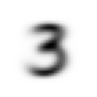

In [17]:
show_image(ideal_3)

<Axes: >

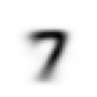

In [18]:
show_image(ideal_7)

Blurry regions => areas where intensity differs significantly across images

Darker regions => areas where pixels consistently have similar intensity across images

### Ex 4: Distance metrics — L1 and L2

In [19]:
valid_threes = (samples / 'valid/3').ls().sorted()
valid_sevens = (samples / 'valid/7').ls().sorted()

len(valid_threes), len(valid_sevens)

(1010, 1028)

In [20]:
valid_3_tens = [tensor(Image.open(p)) for p in valid_threes]
valid_7_tens = [tensor(Image.open(p)) for p in valid_sevens]

len(valid_3_tens), len(valid_7_tens)

(1010, 1028)

In [21]:
stacked_valid_3 = torch.stack(valid_3_tens).float()/255
stacked_valid_7 = torch.stack(valid_7_tens).float()/255

stacked_valid_3.shape, stacked_valid_7.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [22]:
a_3 = stacked_valid_3[0]
a_3.shape

torch.Size([28, 28])

In [23]:
def l1_dist(t1, t2):
    """Mean absolute error"""
    return (t1-t2).abs().mean()

def l2_dist(t1, t2):
    """Root mean squared error"""
    return (t1-t2).pow(2).mean().sqrt()

In [24]:
l1_dist(a_3, ideal_3), l1_dist(a_3, ideal_7), l2_dist(a_3, ideal_3), l2_dist(a_3, ideal_7)

(tensor(0.1280), tensor(0.1530), tensor(0.2328), tensor(0.2896))

In [25]:
# using pytorch methods
F.l1_loss(a_3, ideal_3), F.l1_loss(a_3, ideal_7), F.mse_loss(a_3, ideal_3).sqrt(), F.mse_loss(a_3, ideal_7).sqrt()

(tensor(0.1280), tensor(0.1530), tensor(0.2328), tensor(0.2896))

### Ex 5: Broadcasting and batch classification

In [26]:
def mnist_distance(a, b):
    return (a - b).abs().mean(dim=(-2,-1))

In [27]:
mnist_distance(stacked_valid_3, ideal_3)

tensor([0.1280, 0.1623, 0.1242,  ..., 0.1508, 0.1263, 0.1260])

In [28]:
def is_3(x):
    return mnist_distance(x, ideal_3) < mnist_distance(x, ideal_7)

In [29]:
is_3(stacked_valid_3)

tensor([ True,  True,  True,  ..., False,  True,  True])

In [30]:
valid_3_accuracy = is_3(stacked_valid_3).float().mean()
valid_7_accuracy = (1 - is_3(stacked_valid_7).float()).mean()

valid_3_accuracy, valid_7_accuracy

(tensor(0.9168), tensor(0.9854))

In [31]:
full_accuracy = tensor((valid_3_accuracy, valid_7_accuracy)).mean()
full_accuracy

tensor(0.9511)

#### Alternate implementation
Instead of dealing with `28x28` image matrices, extend each of them to one single vector using `torch.view()`, then compute the mean on the resulting rank-2 tensor.

In [32]:
stacked_valid_3_alt = stacked_valid_3.view(stacked_valid_3.shape[0], math.prod(stacked_valid_3.shape[-2:]))
stacked_valid_7_alt = stacked_valid_7.view(stacked_valid_7.shape[0], math.prod(stacked_valid_7.shape[-2:]))

stacked_valid_3_alt.shape, stacked_valid_7_alt.shape

(torch.Size([1010, 784]), torch.Size([1028, 784]))

In [33]:
def mnist_distance_alt(a, b):
    return (a - b).abs().mean(-1)

In [34]:
mnist_distance_alt(stacked_valid_3_alt, stacked_valid_3_alt.mean(0))

tensor([0.1284, 0.1592, 0.1193,  ..., 0.1534, 0.1228, 0.1202])

In [35]:
def is_3_alt(x):
    return mnist_distance_alt(x, stacked_valid_3_alt.mean(0)) < mnist_distance_alt(x, stacked_valid_7_alt.mean(0))

In [36]:
is_3_alt(stacked_valid_3_alt), is_3_alt(stacked_valid_7_alt)

(tensor([ True,  True,  True,  ..., False,  True,  True]),
 tensor([False, False, False,  ..., False, False, False]))

In [37]:
valid_3_acc_alt = is_3_alt(stacked_valid_3_alt).float().mean()
valid_7_acc_alt = (1 - is_3_alt(stacked_valid_7_alt).float()).mean()

valid_3_acc_alt, valid_7_acc_alt

(tensor(0.9139), tensor(0.9903))

Something made this alternate implementation give slightly different numbers, lower for validation threes and higher for validation sevens. Interesting.

In [38]:
full_acc_alt = tensor((valid_3_acc_alt, valid_7_acc_alt)).mean()
full_acc_alt

tensor(0.9521)

Ever so slightly different from the value produced by the previous implementation.

In [39]:
mnist_distance(stacked_valid_3[0], ideal_3), mnist_distance_alt(stacked_valid_3_alt[0], stacked_valid_3_alt.mean(0))

(tensor(0.1280), tensor(0.1284))

## Section: SGD Foundations

### Ex 6: Parameters and linear prediction

In [40]:
flat_train_3 = stacked_train_3.view(stacked_train_3.shape[0], math.prod(stacked_train_3.shape[-2:]))
flat_train_7 = stacked_train_7.view(stacked_train_7.shape[0], math.prod(stacked_train_7.shape[-2:]))

flat_train_3.shape, flat_train_7.shape

(torch.Size([6131, 784]), torch.Size([6265, 784]))

In [41]:
train_3_labels = tensor([1] * flat_train_3.shape[0])
train_7_labels = tensor([0] * flat_train_7.shape[0])

train_3_labels.shape, train_7_labels.shape

(torch.Size([6131]), torch.Size([6265]))

In [42]:
# combine the 2 together to form one full tensor for the training set
flat_train_all = torch.concat((flat_train_3, flat_train_7))

# use unsqueeze to create a new dimension and therefore
# put each individual label in the same dimension as the pixels for each image
train_labels_all = torch.concat((train_3_labels, train_7_labels)).unsqueeze(1)

flat_train_all.shape, train_labels_all.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

Need to initialize random weights that will be assigned to each pixel. Also need to make sure we can keep track of the gradient of the loss function with respect to each weight.

In [43]:
def init_params(*dims):
    return torch.randn(*dims, requires_grad=True)

We will start with a linear prediction model, of the form `y = mx + c`. `x` will be the pixel data for each image, so `m` and `c` represent the params to be optimized. For deep learning, `m` and `c` are often depicted with `w` (for weight) and `b` (for bias), both together called params.

So, to initialize the weights, the resulting tensor needs 1 dimension whose size matches the number of pixels in each image (`28*28`), and another dimension whose size implies the number of sets of weights we want to apply (and later optimize) for each image. This second dimension size will be `1` because of the specific linear prediction hypothesis we're exploring here: each pixel has a weight, and the weighted sum of the pixels give us **1** prediction. So we only need 1 set of weights for each image.

To initialize the bias, we need one scalar tensor for each set of weights. One scalar tensor per set of weights stems from the objective of the bias, which is to shift the output prediction in positive or negative direction, independent of the input `x`. So the weights assign importance to each pixel, and the bias provides a lever for shifting the final weighted sum towards the actual target value in a way that's independent of the pixel values. Therefore, the bias will be a vector with as many dimensions as there are sets of weights, which in this case is `1`.

In [44]:
w1 = init_params(flat_train_all.shape[-1], 1)
b1 = init_params(1)

w1.shape, b1

(torch.Size([784, 1]), tensor([0.3472], requires_grad=True))

Let's test a prediction with these values. This means we need to test the matrix multiplication of image data with the weights (which gives the weighted sum) and then add the bias. Let's try this with the first image. We'll use the transpose of the weights and manually calculate the sum because the `*` operator does only element-wise multiplication instead of regular matrix multiplication.

In [45]:
# use no_grad() to prevent tracking gradients during the operation
with torch.no_grad():
    pred_val = (flat_train_all[0]*w1.T).sum()
    print(f'Predicted value for image 0: {pred_val}')

Predicted value for image 0: -6.580235481262207


Now let's use matrix multiplication to handle all the images.

In [46]:
with torch.no_grad():
    print(flat_train_all@w1 + b1)

tensor([[ -6.2330],
        [-10.6388],
        [-20.8865],
        ...,
        [-15.9176],
        [ -1.6866],
        [-11.3568]])


In [47]:
def linear_model(x_img):
    return x_img@w1 + b1

In [48]:
with torch.no_grad():
    preds = linear_model(flat_train_all)
    print(f'Predicted values for all images: {preds}')

Predicted values for all images: tensor([[ -6.2330],
        [-10.6388],
        [-20.8865],
        ...,
        [-15.9176],
        [ -1.6866],
        [-11.3568]])


The values for the first image are about the same, so seems like same ball park.

In [49]:
preds.shape

torch.Size([12396, 1])

### Ex 7: Loss — why MSE breaks for classification

First, let's compute accuracy on a mini-batch. Mini-batches are used for managing the amount of computational work done per epoch. We'll break up the images into mini-batches of 32.

In [50]:
dset = list(zip(flat_train_all, train_labels_all))
len(dset)

12396

In [51]:
train_dl = DataLoader(dset, bs=32, shuffle=True)
mb_1 = next(iter(train_dl))
mb_1

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([[1],
         [0],
         [0],
         [1],
         [0],
         [0],
         [0],
         [1],
         [0],
         [0],
         [0],
         [0],
         [0],
         [1],
         [1],
         [1],
         [1],
         [1],
         [0],
         [0],
         [1],
         [1],
         [0],
         [0],
         [1],
         [1],
         [1],
         [0],
         [0],
         [0],
         [1],
         [0]]))

To compute accuracy, we need to pick a decision point where a value crosses from one category to the next. We'll use 0, so negative values become one category and positive values become the other category. Note that this then means that we're labeling negative values with a class of `0` and positive values with a class of `1`, but this `0` label is different from the `0` threshold in the output of the linear model. Notice the flattening effect of this method: the distance of a prediction from the decision boundary has no effect on the accuracy value.

In [52]:
def batch_accuracy(batch):
    data, labels = batch
    batch_preds = linear_model(data)
    preds_categories = torch.where(batch_preds > 0, 1, 0)
    return torch.where(preds_categories == labels, 1, 0).float().mean()

In [53]:
with torch.no_grad():
    print(batch_accuracy(mb_1))

tensor(0.5625)


As mentioned earlier, accuracy only changes when the predictions are close enough to the threshold for small changes to nudge them into the correct territory. Apart from that, accuracy is essentially insensitive to small changes to the weights. Let's see this in action.

In [54]:
w1[0]

tensor([1.9269], grad_fn=<SelectBackward0>)

In [55]:
# tweak one the weights slightly to see if that has any effect on accuracy
with torch.no_grad():
    w1[0] *= 1.0001

w1[0]

tensor([1.9271], grad_fn=<SelectBackward0>)

In [56]:
with torch.no_grad():
    print(batch_accuracy(mb_1))

tensor(0.5625)


No noticeable effect. This shows that accuracy is not a good loss function.

The loss function has to be responsive to small changes in weights, to ensure that SGD can continuously push the weights towards increasingly accurate predictions. In graphical terms, the graph of accuracy vs weights (i.e. the graph of this loss function) is flat (value of `0`) when not at the decision boundary, because no change in weights will result in a change in accuracy. Then at the boundary, the graph is undefined because a change in weights can tilt the accuracy significantly as the categories change. As such, SGD has nothing to reliably follow, making accuracy a poor loss function for SGD.

### Ex 8: A better loss — sigmoid and mnist_loss

The sigmoid function transforms all values into a value between `0` and `1`. More specifically, if its input is the result of a calculation that represents a prediction, its output will represent a probability of that prediction being correct.

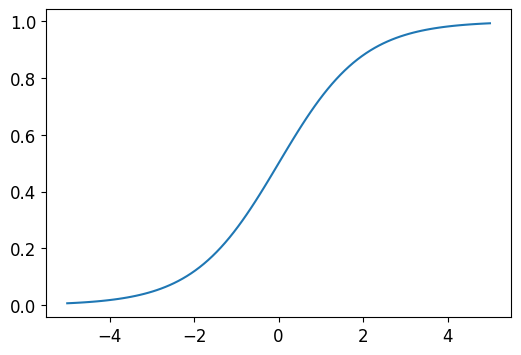

In [57]:
plot_function(F.sigmoid, min=-5, max=5)

We'll use the sigmoid function to get probabilities out of our loss values. The key improvement that this brings is that it accounts for the distance from the decision boundary. The further the value is from the boundary, the stronger that value represents one of the categories; and in reverse, the closer it is to the decision boundary, the less confident the prediction for either category. This allows SGD to follow the relationship smoothly and progressively optimize towards more confident predictions.

In [58]:
def mnist_loss(preds, target):
    preds = F.sigmoid(preds)
    return torch.where(target==1, 1 - preds, preds).mean()

In [59]:
with torch.no_grad():
    loss = mnist_loss(
        linear_model(mb_1[0]),
        mb_1[1]
    )
    print(loss)

tensor(0.4356)


## Section: Training Loop

### Ex 9: Gradients — requires_grad, .backward(), .grad

To explore gradients and how they affect the loss values, let's define a function that will perform a full run through the SGD process.

In [60]:
def calc_grad(batch):
    data, labels = batch
    preds = linear_model(data)
    loss = mnist_loss(preds, labels)
    # calculate the gradient
    loss.backward()
    print("weights grad:", w1.grad)
    print("bias grad:", b1.grad)

In [61]:
# first of 3 invocations
calc_grad(mb_1)

weights grad: tensor([[ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00

In [62]:
# second of 3 invocations
calc_grad(mb_1)

weights grad: tensor([[ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00

In [63]:
# third of 3 invocations
calc_grad(mb_1)

weights grad: tensor([[ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 0.0000e+00

We can see that the gradient is changing each time because pytorch is keeping tracking of the operations being run on the params. This is what `requires_grad` does, making it easy to know the gradient of the params at any point in time. This is necessary for SGD because the gradient is what's used to progressively descend closer and closer to the optimized weights.

However, as we can see, it's essential to zero out the gradients between steps that need a fresh gradient calculation, otherwise pytorch will track old operations as if they're all contributing to the current gradient.

In [64]:
w1.grad.zero_()
b1.grad.zero_()

w1.grad, b1.grad

(tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [

### Ex 10: The training loop — one full SGD cycle

We'll now implement the full SGD loop.

In [65]:
def train_epoch(model, lr, params):
    losses = []
    for batch in train_dl:
        data, labels = batch
        # make predictions
        preds = model(data)
        # calculate loss
        loss = mnist_loss(preds, labels)
        losses.append(loss.item())
        # calculate gradient
        loss.backward()
        
        for p in params:
            # update params with gradient
            p.data -= p.grad * lr
            # zero param gradients
            p.grad.zero_()

    return tensor(losses).mean()

In [66]:
# create the validation dataset
flat_valid_all = torch.concat((stacked_valid_3_alt, stacked_valid_7_alt))
valid_labels_all = tensor([1] * stacked_valid_3_alt.shape[0] + [0] * stacked_valid_7_alt.shape[0]).unsqueeze(1)

flat_valid_all.shape, valid_labels_all.shape

(torch.Size([2038, 784]), torch.Size([2038, 1]))

In [67]:
valid_dset = list(zip(flat_valid_all, valid_labels_all))
valid_dl = DataLoader(valid_dset, bs=32, shuffle=True)
valid_dl

In [68]:
def batch_acc(preds, target):
    return ((preds.sigmoid() > 0.5) == target).float().mean()

In [69]:
def validate_epoch(model):
    with torch.no_grad():
        mean_acc = tensor([batch_acc(model(batch[0]), batch[1]) for batch in valid_dl]).mean()

    return mean_acc

In [70]:
for i in range(20):
    epoch_loss = train_epoch(linear_model, 0.1, [w1, b1])
    epoch_acc = validate_epoch(linear_model)
    print(f"[Epoch {i + 1}] loss:", epoch_loss, "accuracy:", epoch_acc)

[Epoch 1] loss: tensor(0.2747) accuracy: tensor(0.8589)
[Epoch 2] loss: tensor(0.1174) accuracy: tensor(0.9197)
[Epoch 3] loss: tensor(0.0822) accuracy: tensor(0.9392)
[Epoch 4] loss: tensor(0.0655) accuracy: tensor(0.9470)
[Epoch 5] loss: tensor(0.0556) accuracy: tensor(0.9539)
[Epoch 6] loss: tensor(0.0493) accuracy: tensor(0.9581)
[Epoch 7] loss: tensor(0.0448) accuracy: tensor(0.9593)
[Epoch 8] loss: tensor(0.0416) accuracy: tensor(0.9602)
[Epoch 9] loss: tensor(0.0389) accuracy: tensor(0.9602)
[Epoch 10] loss: tensor(0.0368) accuracy: tensor(0.9619)
[Epoch 11] loss: tensor(0.0352) accuracy: tensor(0.9619)
[Epoch 12] loss: tensor(0.0337) accuracy: tensor(0.9624)
[Epoch 13] loss: tensor(0.0324) accuracy: tensor(0.9629)
[Epoch 14] loss: tensor(0.0313) accuracy: tensor(0.9634)
[Epoch 15] loss: tensor(0.0303) accuracy: tensor(0.9639)
[Epoch 16] loss: tensor(0.0296) accuracy: tensor(0.9656)
[Epoch 17] loss: tensor(0.0289) accuracy: tensor(0.9668)
[Epoch 18] loss: tensor(0.0281) accuracy

## Section: Abstractions & Depth

### Ex 11: fastai abstractions — DataLoader, Learner, and fit

Now we'll implement the same function using fastai abstractions.

In [71]:
# use larger batch size in the data loaders
train_dl = DataLoader(dset, batch_size=256, shuffle=True)
valid_dl = DataLoader(valid_dset, batch_size=256, shuffle=True)

train_dl, valid_dl

(<fastai.data.load.DataLoader at 0x783d889865d0>,
 <fastai.data.load.DataLoader at 0x783d88986360>)

In [72]:
learn = Learner(
    dls=DataLoaders(train_dl, valid_dl),
    model=nn.Linear(flat_train_all.shape[-1], 1),
    loss_func=mnist_loss,
    opt_func=SGD,
    metrics=batch_acc,
)
learn

In [73]:
learn.fit(10, 1.)

epoch,train_loss,valid_loss,batch_acc,time
0,0.058023,0.041157,0.972031,00:00
1,0.039906,0.035990,0.973994,00:00
2,0.031958,0.031799,0.976448,00:00
3,0.028241,0.029841,0.976938,00:00
4,0.025452,0.028239,0.978901,00:00
5,0.023462,0.027213,0.979392,00:00
6,0.022163,0.026407,0.978901,00:00
7,0.021107,0.025880,0.979392,00:00
8,0.020570,0.024879,0.979392,00:00
9,0.020154,0.024634,0.980373,00:00


We'll now update the model to use a simple neural net. This neural net will contain 2 linear models separated by a ReLU function.

In [74]:
simple_net = nn.Sequential(
    nn.Linear(flat_train_all.shape[-1], 30),
    nn.ReLU(),
    nn.Linear(30, 1)
)

In [75]:
learn = Learner(
    dls=DataLoaders(train_dl, valid_dl),
    model=simple_net,
    loss_func=mnist_loss,
    opt_func=SGD,
    metrics=batch_acc,
)

In [76]:
learn.fit(10, 1.)

epoch,train_loss,valid_loss,batch_acc,time
0,0.055778,0.035522,0.970069,00:00
1,0.031045,0.025807,0.976938,00:00
2,0.022732,0.022064,0.981845,00:00
3,0.018724,0.020761,0.981354,00:00
4,0.016933,0.020108,0.982336,00:00
5,0.015322,0.018735,0.983317,00:00
6,0.014406,0.017872,0.985280,00:00
7,0.013777,0.018103,0.983808,00:00
8,0.012670,0.016575,0.986261,00:00
9,0.012346,0.016903,0.984789,00:00


### Ex 12: Why nonlinearity — ReLU and depth

Stacking multiple linear models opens up the possibility of learning different useful relationships betweent the pixels. However, because of the mathematical reality that matrix multiplication between 2 matrices just yields another matrix, we must introduce something that prevents the 2 linear models from collapsing into one, so that they can learn the relationships distinctly. This is what the ReLU function does. It sets all negative values to 0 and allows positive values to pass through unchanged.

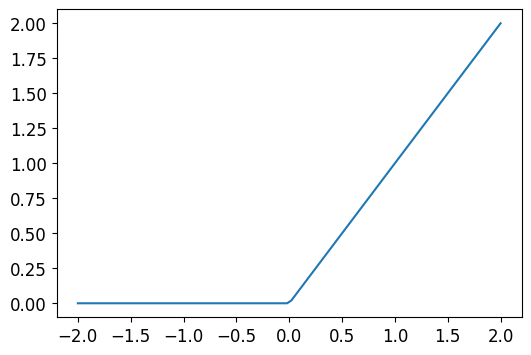

In [77]:
plot_function(torch.relu)

Putting this function between 2 linear functions makes the operation non-linear and uncollapsible into a single matrix operation. This outcome imposes some interesting characteristics on the model:

- the model gains the ability to effectively silence some of the relationships that are represented in the inner layer. When some pixels are activated by certain inputs, the weights assigned to those pixels can turns those values negative and therefore cause those pixels to make no contribution to the final prediction that originates beyond the first layer. So the model can optimize the weights to take advantage of the fact that some relationships that are not strongly predictive on some inputs can be diminished across the ReLU boundary
- that phenomenon introduces conditionality into the relationships learned by the model. Each input will traverse a distinct (and likely unique) path from the innermost layer to final outermost prediction, and the ReLU will dictate which relationships the input will be able to activate en route to the final activation
- according to the universal approximation theorem, the combination of linear model and ReLU enables the modeling of any arbitrarily complex curve.